In [1]:
!pip install langchain_google_genai

In [2]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.messages import RemoveMessage

In [ ]:
load_dotenv()

# Set your Google API key here
api_key = ""  # Replace with your actual key

if not api_key or api_key == "YOUR_API_KEY_HERE":
    raise ValueError("Please set api_key to your actual GOOGLE_API_KEY")

In [4]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", 
    api_key=api_key,
    streaming=True
)

In [5]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [18]:
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import InMemorySaver

# 1. Initialize the Graph with your State schema
builder = StateGraph(MessagesState)

# 2. Add the nodes 
# The first argument is the "Nickname" for the node used in edges
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages) 

# 3. Define the flow (Edges)
builder.add_edge(START, "chat")      # Start -> Chat
builder.add_edge("chat", "cleanup")   # Chat -> Cleanup
builder.add_edge("cleanup", END)      # Cleanup -> End

# 4. Compile with memory
memory = InMemorySaver()
graph = builder.compile(checkpointer=memory)

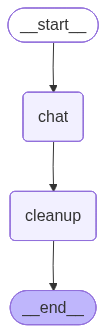

In [19]:
graph 

In [20]:
config = {"configurable": {"thread_id": "t1"}}

In [21]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Poras Nehra "}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='984be520-1694-4719-985e-3fa8f35beb61'),
  AIMessage(content='Okay Poras, let\'s zoom out a bit. If LangGraph is the conductor of a complex symphony, then **LangChain** is the entire orchestra – the instruments, the sheet music, the musicians, and even some simpler arrangements.\n\n**LangChain is a comprehensive framework designed to simplify the development of applications powered by Large Language Models (LLMs).**\n\nIts primary goal is to make it easier to connect LLMs with other sources of data and computation, allowing you to build much more powerful and sophisticated AI applications than just calling an LLM directly.\n\n### The Problem LangChain Solves\n\nWorking with raw LLMs often involves several challenges:\n\n1.  **Prompt Engineering:** Crafting effective prompts is an art, and managing complex prompts (with examples, instructions, etc.) can be cumbersome.\n2.  **Context Ma

In [22]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
